# 门源数据诊断

逐步排查 PGV 场只出现小点的原因

In [1]:
%matplotlib inline
from pathlib import Path
from datetime import datetime, timezone, timedelta

import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend, butter, filtfilt
from scipy.integrate import cumulative_trapezoid
from scipy.ndimage import gaussian_filter
H5_PATH    = Path("Menyuan/Menyuan.h5")   # 你的 HDF5 文件
EQ_ORIGIN  = datetime(2022, 1, 7, 17, 45, 30, tzinfo=timezone.utc)
CST        = timezone(timedelta(hours=8))

GRID_SIZE   = 150
RESOLUTION  = 0.01
RECORD_PRETRIGGER_S = 0.0
RECORD_TIME_IS_TRIGGER = True

## 1. 检查 H5 文件结构与台站基本信息

In [2]:
with h5py.File(H5_PATH, "r") as f:
    eq = f["earthquake"]
    EQ_LAT = float(eq.attrs["latitude"])
    EQ_LON = float(eq.attrs["longitude"])
    EQ_MAG = float(eq.attrs["magnitude"])
    EQ_DEP = float(eq.attrs["depth"])
    h5_origin = eq.attrs.get("origin_time", "N/A")

    print(f"=== 震源信息 ===")
    print(f"  H5 origin_time : {h5_origin}")
    print(f"  Manual origin  : {EQ_ORIGIN.isoformat()}")
    print(f"  Lat={EQ_LAT}, Lon={EQ_LON}, M={EQ_MAG}, dep={EQ_DEP}km")

    half    = GRID_SIZE * RESOLUTION * 0.5
    lon_min = EQ_LON - half;  lon_max = EQ_LON + half
    lat_min = EQ_LAT - half;  lat_max = EQ_LAT + half
    print(f"\n=== 网格范围 ===")
    print(f"  Lon: [{lon_min:.4f}, {lon_max:.4f}]")
    print(f"  Lat: [{lat_min:.4f}, {lat_max:.4f}]")

    sta_root   = f["stations"]
    all_sta    = list(sta_root.keys())
    print(f"\n=== 台站总数: {len(all_sta)} ===")

    rows = []
    for sid in all_sta:
        g  = sta_root[sid]
        lo = float(g.attrs.get("longitude", 0))
        la = float(g.attrs.get("latitude",  0))
        sr = float(g.attrs.get("sampling_rate", 100))
        rt = g.attrs.get("record_time", "")
        in_grid = (lon_min <= lo <= lon_max) and (lat_min <= la <= lat_max)

        # 计算 rec_offset_s
        try:
            dt = datetime.fromisoformat(str(rt))
            if dt.tzinfo is None:
                dt = dt.replace(tzinfo=CST)
            if RECORD_TIME_IS_TRIGGER:
                rec_start = dt - timedelta(seconds=RECORD_PRETRIGGER_S)
            else:
                rec_start = dt
            rec_offset = (rec_start - EQ_ORIGIN).total_seconds()
        except Exception:
            rec_offset = float('nan')

        # waveform 长度
        wlen = 0
        if "waveforms" in g:
            for ch in ['UD','EW','NS']:
                if ch in g["waveforms"]:
                    wlen = len(g["waveforms"][ch])
                    break

        rows.append(dict(id=sid, lon=lo, lat=la, sr=sr,
                         record_time=str(rt),
                         rec_offset_s=rec_offset,
                         wlen=wlen,
                         in_grid=in_grid))

in_grid_rows = [r for r in rows if r['in_grid']]
print(f"\n网格内台站数: {len(in_grid_rows)} / {len(rows)}")

print("\n=== 前 10 个网格内台站的 rec_offset_s ===")
for r in in_grid_rows[:10]:
    print(f"  {r['id']:20s} record_time={r['record_time']}  "
          f"rec_offset={r['rec_offset_s']:.1f}s  wlen={r['wlen']}")

=== 震源信息 ===
  H5 origin_time : 2022-01-08T01:45:00
  Manual origin  : 2022-01-07T17:45:30+00:00
  Lat=37.77, Lon=101.26, M=6.9, dep=10.0km

=== 网格范围 ===
  Lon: [100.5100, 102.0100]
  Lat: [37.0200, 38.5200]

=== 台站总数: 79 ===

网格内台站数: 61 / 79

=== 前 10 个网格内台站的 rec_offset_s ===
  GS.C0003             record_time=2022-01-08T01:45:10  rec_offset=-20.0s  wlen=8000
  GS.C0004             record_time=2022-01-08T01:45:10  rec_offset=-20.0s  wlen=8000
  GS.C0005             record_time=2022-01-08T01:45:10  rec_offset=-20.0s  wlen=8000
  GS.C0008             record_time=2022-01-08T01:45:10  rec_offset=-20.0s  wlen=8000
  GS.G0002             record_time=2022-01-08T01:45:10  rec_offset=-20.0s  wlen=8000
  GS.G0004             record_time=2022-01-08T01:45:10  rec_offset=-20.0s  wlen=8000
  GS.G0005             record_time=2022-01-08T01:45:10  rec_offset=-20.0s  wlen=8000
  GS.G0006             record_time=2022-01-08T01:45:10  rec_offset=-20.0s  wlen=8000
  GS.G0008             record_time=2022-01

## 2. 检查 rec_offset_s 分布

如果大量台站 rec_offset_s > 40s，说明记录在模型时间窗内还未开始，PGV 全为 0。

rec_offset_s 统计（网格内 61 台站）:
  min=-20.0s  max=-20.0s  mean=-20.0s  median=-20.0s

  rec_offset < 0  (记录在震源前开始): 61 台
  0 <= rec_offset <= 40s (正常范围):  0 台
  rec_offset > 40s (超出时间窗！):    0 台


/tmp/ipykernel_2470/914588891.py:26: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/914588891.py:26: UserWarning: Glyph 31449 (\N{CJK UNIFIED IDEOGRAPH-7AD9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/914588891.py:26: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/914588891.py:26: UserWarning: Glyph 35760 (\N{CJK UNIFIED IDEOGRAPH-8BB0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/914588891.py:26: UserWarning: Glyph 24405 (\N{CJK UNIFIED IDEOGRAPH-5F55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/914588891.py:26: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/914588891.py:26: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missi

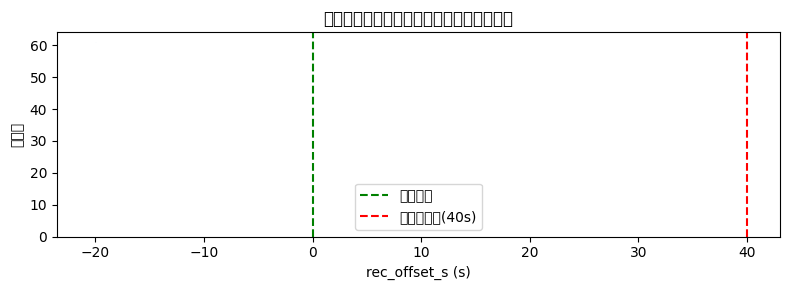

In [3]:
offsets = np.array([r['rec_offset_s'] for r in in_grid_rows
                    if np.isfinite(r['rec_offset_s'])])

print(f"rec_offset_s 统计（网格内 {len(offsets)} 台站）:")
print(f"  min={offsets.min():.1f}s  max={offsets.max():.1f}s"
      f"  mean={offsets.mean():.1f}s  median={np.median(offsets):.1f}s")
print()


too_late = np.sum(offsets > 40)
negative = np.sum(offsets < 0)
normal   = np.sum((offsets >= 0) & (offsets <= 40))

print(f"  rec_offset < 0  (记录在震源前开始): {negative} 台")
print(f"  0 <= rec_offset <= 40s (正常范围):  {normal} 台")
print(f"  rec_offset > 40s (超出时间窗！):    {too_late} 台")

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(offsets, bins=30, color='steelblue', edgecolor='white')
ax.axvline(0,  color='green',  linestyle='--', label='震源时刻')
ax.axvline(40, color='red',    linestyle='--', label='时间窗上限(40s)')
ax.set_xlabel('rec_offset_s (s)')
ax.set_ylabel('台站数')
ax.set_title('台站记录起始时刻相对震源时刻的偏移分布')
ax.legend()
plt.tight_layout()
plt.show()

## 3. 检查台站空间分布

/tmp/ipykernel_2470/3121646680.py:25: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3121646680.py:25: UserWarning: Glyph 31449 (\N{CJK UNIFIED IDEOGRAPH-7AD9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3121646680.py:25: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3121646680.py:25: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3121646680.py:25: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3121646680.py:25: UserWarning: Glyph 39068 (\N{CJK UNIFIED IDEOGRAPH-989C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3121646680.py:25: UserWarning: Glyph 33394 (\N{CJK UNIFIED IDEOGRAPH-8272}

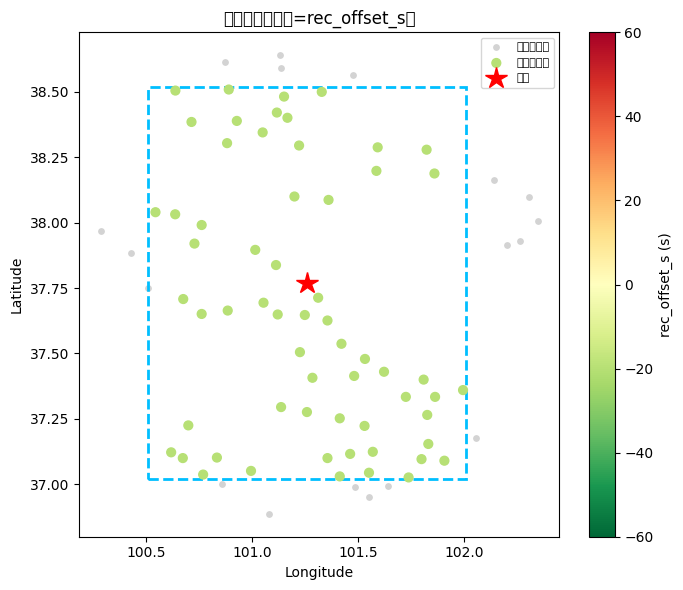

In [4]:
fig, ax = plt.subplots(figsize=(7, 6))

lons_all = [r['lon'] for r in rows]
lats_all = [r['lat'] for r in rows]
ax.scatter(lons_all, lats_all, c='lightgray', s=15, label='网格外台站')

lons_in  = [r['lon'] for r in in_grid_rows]
lats_in  = [r['lat'] for r in in_grid_rows]
offs_in  = [r['rec_offset_s'] for r in in_grid_rows]
sc = ax.scatter(lons_in, lats_in, c=offs_in, cmap='RdYlGn_r',
                s=40, vmin=-60, vmax=60, zorder=5, label='网格内台站')
plt.colorbar(sc, ax=ax, label='rec_offset_s (s)')

# 网格范围框
import matplotlib.patches as mpatches
rect = mpatches.Rectangle(
    (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
    linewidth=2, edgecolor='deepskyblue', facecolor='none', linestyle='--')
ax.add_patch(rect)

ax.plot(EQ_LON, EQ_LAT, 'r*', markersize=16, zorder=10, label='震中')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('台站分布（颜色=rec_offset_s）')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. 检查单个台站的原始波形和处理后速度

/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 30456 (\N{CJK UNIFIED IDEOGRAPH-76F8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 35760 (\N{CJK UNIFIED IDEOGRAPH-8BB0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 24405 (\N{CJK UNIFIED IDEOGRAPH-5F55}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 36215 (\N{CJK UNIFIED IDEOGRAPH-8D77}

检查台站: GS.C0003
  rec_offset_s = -20.0s
  record_time  = 2022-01-08T01:45:10
  sr=100.0 Hz, wlen=8000 pts
  record duration = 80.0s
  channels: ['EW', 'NS', 'UD']


/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 36895 (\N{CJK UNIFIED IDEOGRAPH-901F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 38663 (\N{CJK UNIFIED IDEOGRAPH-9707}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/1587298540.py:59: UserWarning: Glyph 28304 (\N{CJK UNIFIED IDEOGRAPH-6E90}

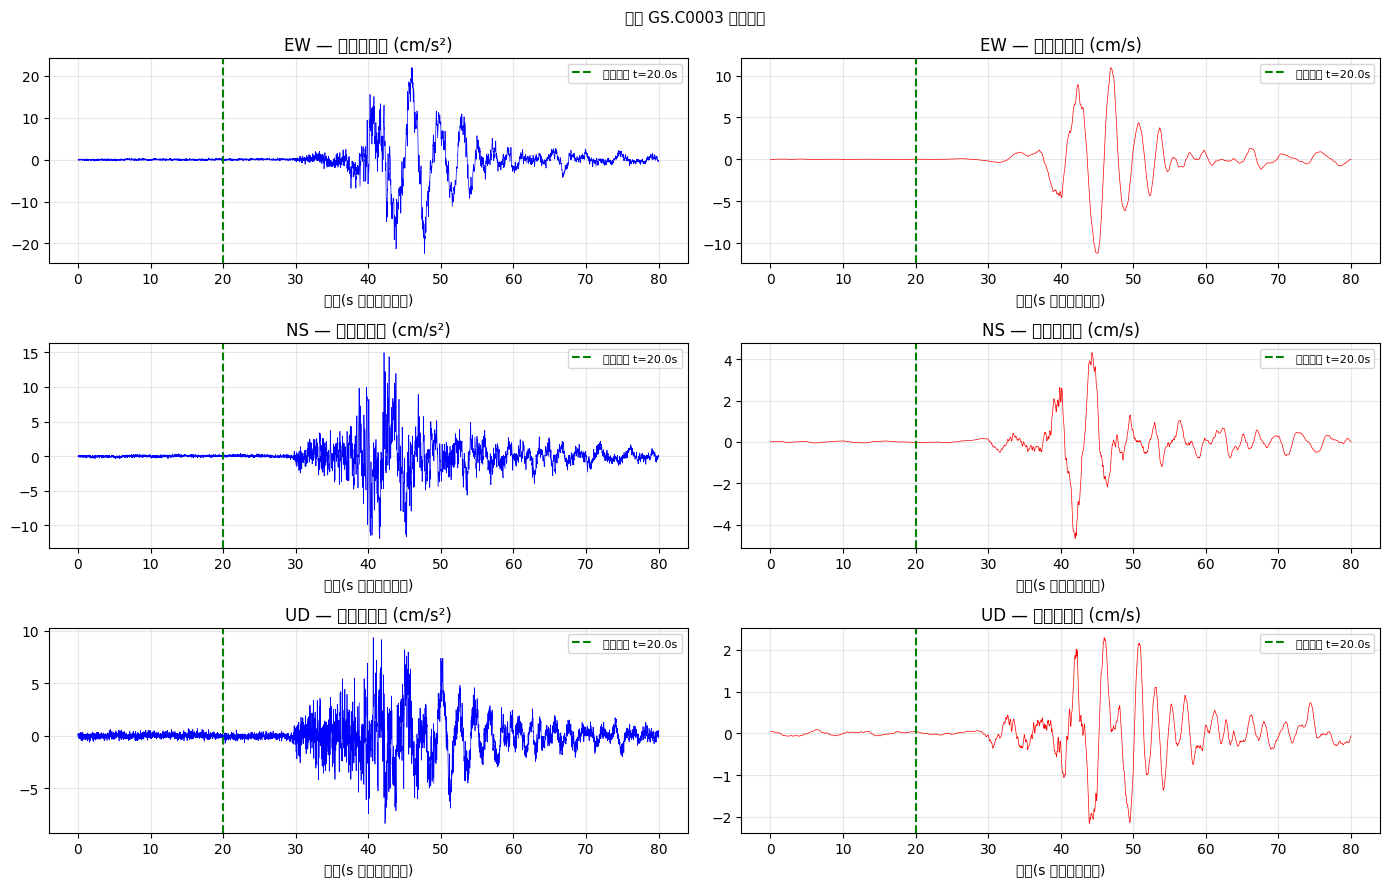

In [5]:
# 取网格内 rec_offset_s 最小（最早触发）的台站做检查
in_grid_finite = [r for r in in_grid_rows
                  if np.isfinite(r['rec_offset_s'])]
in_grid_sorted = sorted(in_grid_finite, key=lambda r: r['rec_offset_s'])

sta_check = in_grid_sorted[0]  # 最早触发的台站
print(f"检查台站: {sta_check['id']}")
print(f"  rec_offset_s = {sta_check['rec_offset_s']:.1f}s")
print(f"  record_time  = {sta_check['record_time']}")
print(f"  sr={sta_check['sr']} Hz, wlen={sta_check['wlen']} pts")
print(f"  record duration = {sta_check['wlen']/sta_check['sr']:.1f}s")

with h5py.File(H5_PATH, "r") as f:
    wgrp = f['stations'][sta_check['id']]['waveforms']
    channels = list(wgrp.keys())
    print(f"  channels: {channels}")

    # 读取各分量
    data_dict = {ch: np.array(wgrp[ch], dtype=np.float32) for ch in channels}

sr = sta_check['sr']
fig, axes = plt.subplots(len(channels), 2,
                          figsize=(14, 3*len(channels)), squeeze=False)

for i, ch in enumerate(channels):
    raw = data_dict[ch]
    t   = np.arange(len(raw)) / sr

    # 简单预处理
    n_pre = min(int(3.0 * sr), len(raw))
    baseline = float(np.median(raw[:n_pre]))
    x = detrend(raw - baseline, type='linear').astype(np.float32)
    nyq = 0.5 * sr
    b, a = butter(3, [0.1/nyq, min(10.0/nyq, 0.999)], btype='band')
    acc_proc = filtfilt(b, a, x)
    vel = cumulative_trapezoid(acc_proc, dx=1/sr, initial=0.0)
    vel = detrend(vel, type='linear')
    b2, a2 = butter(2, 0.05/nyq, btype='high')
    vel = filtfilt(b2, a2, vel)

    axes[i, 0].plot(t, raw, 'b-', lw=0.5)
    axes[i, 0].set_title(f'{ch} — 原始加速度 (cm/s²)')
    axes[i, 0].set_xlabel('时间(s 相对记录起点)')
    axes[i, 0].grid(alpha=0.3)

    axes[i, 1].plot(t, vel, 'r-', lw=0.5)
    axes[i, 1].set_title(f'{ch} — 处理后速度 (cm/s)')
    axes[i, 1].set_xlabel('时间(s 相对记录起点)')
    axes[i, 1].grid(alpha=0.3)

    # 标记震源时刻（在记录中的位置）
    t_eq_in_rec = -sta_check['rec_offset_s']  # 震源时刻在记录中的位置
    for ax in axes[i]:
        ax.axvline(t_eq_in_rec, color='green',
                   linestyle='--', label=f'震源时刻 t={t_eq_in_rec:.1f}s')
        ax.legend(fontsize=8)

plt.suptitle(f'台站 {sta_check["id"]} 波形检查', fontsize=11)
plt.tight_layout()
plt.show()

## 5. 检查 PGV 场（直接构建，观察是否只有中心点）

读取台站: 61 个

PGV 统计:
  max=26.9451  min=0.4787  mean=3.2044  median=1.8719 cm/s
  PGV < 1e-6 的台站: 0 个（可能波形全为零）


/tmp/ipykernel_2470/3505108631.py:72: UserWarning: Glyph 21488 (\N{CJK UNIFIED IDEOGRAPH-53F0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3505108631.py:72: UserWarning: Glyph 31449 (\N{CJK UNIFIED IDEOGRAPH-7AD9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3505108631.py:72: UserWarning: Glyph 31354 (\N{CJK UNIFIED IDEOGRAPH-7A7A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3505108631.py:72: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3505108631.py:72: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3505108631.py:72: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/3505108631.py:72: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

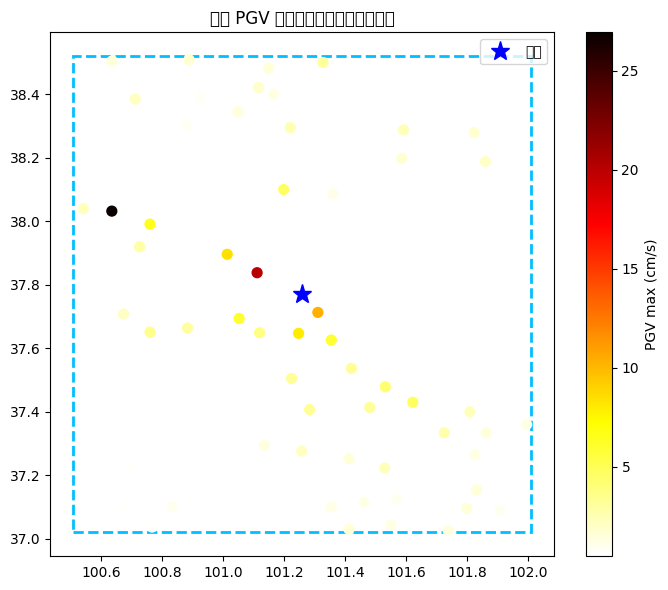

In [6]:
def preprocess_acc_to_vel(acc, sr, pre_event_s=3.0):
    x = np.asarray(acc, dtype=np.float32).reshape(-1)
    if len(x) == 0:
        return x, x
    n_pre = min(int(pre_event_s * sr), len(x))
    baseline = float(np.median(x[:n_pre])) if n_pre > 16 else float(np.median(x))
    x = detrend(x - baseline, type='linear').astype(np.float32)
    nyq = 0.5 * sr
    hp, lp = max(0.1/nyq, 1e-5), min(10.0/nyq, 0.999)
    b, a = butter(3, [hp, lp], btype='band') if hp < lp else butter(3, hp, btype='high')
    acc_proc = filtfilt(b, a, x).astype(np.float32)
    vel = cumulative_trapezoid(acc_proc, dx=1.0/sr, initial=0.0).astype(np.float32)
    vel = detrend(vel, type='linear').astype(np.float32)
    hp2 = max(0.05/nyq, 1e-5)
    if hp2 < 0.999:
        b2, a2 = butter(2, hp2, btype='high')
        vel = filtfilt(b2, a2, vel).astype(np.float32)
    return acc_proc, vel


# 读取所有网格内台站的波形，计算 PGV
CHANNEL_PRIORITY = ['UD', 'EW', 'NS']

stations = []
with h5py.File(H5_PATH, "r") as f:
    for r in in_grid_finite:
        g = f['stations'][r['id']]
        if 'waveforms' not in g:
            continue
        acc_raw = None
        for ch in CHANNEL_PRIORITY:
            if ch in g['waveforms']:
                arr = np.array(g['waveforms'][ch], dtype=np.float32)
                if arr.size > 0:
                    acc_raw = arr; break
        if acc_raw is None:
            continue

        acc_proc, vel = preprocess_acc_to_vel(acc_raw, r['sr'])
        stations.append({
            'id': r['id'], 'lon': r['lon'], 'lat': r['lat'],
            'sr': r['sr'], 'rec_offset_s': r['rec_offset_s'],
            'vel': vel, 'acc': acc_proc,
            'pgv_max': float(np.max(np.abs(vel))),
        })

print(f"读取台站: {len(stations)} 个")
print()
print("PGV 统计:")
pgvs = np.array([s['pgv_max'] for s in stations])
print(f"  max={pgvs.max():.4f}  min={pgvs.min():.4f}  "
      f"mean={pgvs.mean():.4f}  median={np.median(pgvs):.4f} cm/s")
zero_sta = np.sum(pgvs < 1e-6)
print(f"  PGV < 1e-6 的台站: {zero_sta} 个（可能波形全为零）")

# 快速 PGV 空间分布
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(
    [s['lon'] for s in stations],
    [s['lat'] for s in stations],
    c=[s['pgv_max'] for s in stations],
    cmap='hot_r', s=50, zorder=5
)
plt.colorbar(sc, ax=ax, label='PGV max (cm/s)')
ax.plot(EQ_LON, EQ_LAT, 'b*', markersize=14, zorder=10, label='震中')
rect = mpatches.Rectangle(
    (lon_min, lat_min), lon_max-lon_min, lat_max-lat_min,
    linewidth=2, edgecolor='deepskyblue', facecolor='none', linestyle='--')
ax.add_patch(rect)
ax.set_title('台站 PGV 空间分布（全记录最大值）')
ax.legend()
plt.tight_layout()
plt.show()

## 6. 检查 PGV 场随时间的演化

检查模型实际看到的输入场是什么样子。

各时刻活跃（非零）台站数:
  t=6.8s → 活跃台站 61/61, max_pgv=13.76954 cm/s
  t=13.6s → 活跃台站 61/61, max_pgv=20.09065 cm/s
  t=20.3s → 活跃台站 61/61, max_pgv=20.09065 cm/s
  t=27.1s → 活跃台站 61/61, max_pgv=20.09065 cm/s
  t=33.9s → 活跃台站 61/61, max_pgv=20.09065 cm/s
  t=40.0s → 活跃台站 61/61, max_pgv=26.94513 cm/s


/tmp/ipykernel_2470/2028629342.py:75: UserWarning: Glyph 25554 (\N{CJK UNIFIED IDEOGRAPH-63D2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/2028629342.py:75: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/2028629342.py:75: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/2028629342.py:75: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/2028629342.py:75: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/2028629342.py:75: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2470/2028629342.py:75: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}

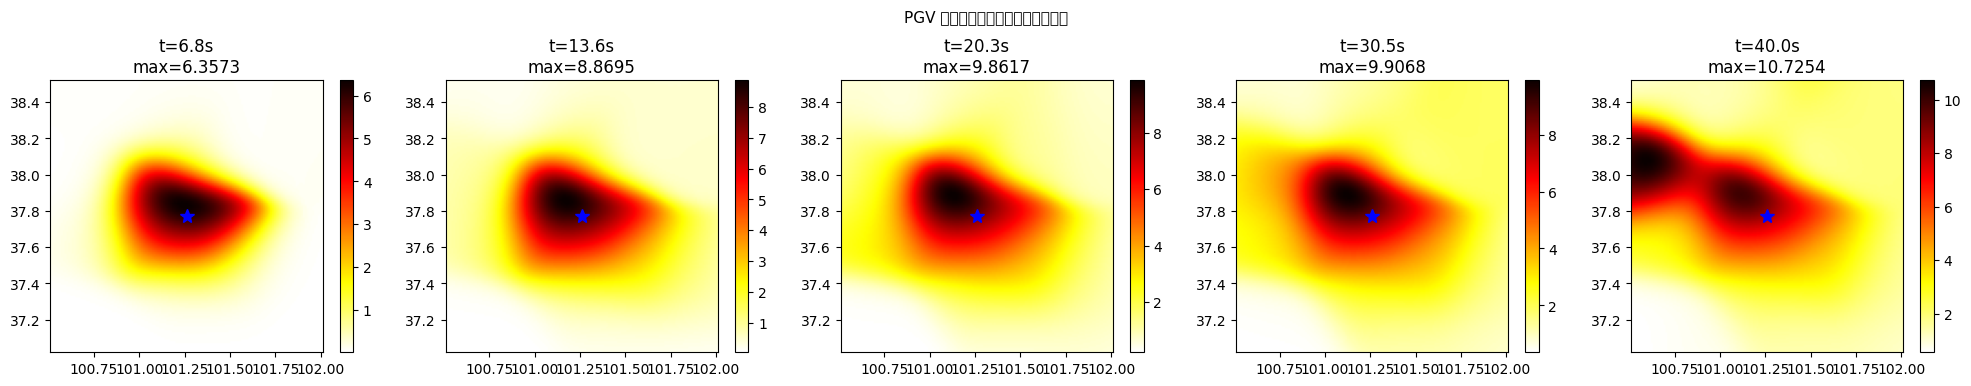

In [7]:
TOTAL_DUR   = 40.0
N_TIMESTEPS = 60
WIN_S       = 2.0

grid_lon_vec = np.linspace(lon_min, lon_max, GRID_SIZE, dtype=np.float32)
grid_lat_vec = np.linspace(lat_min, lat_max, GRID_SIZE, dtype=np.float32)
grid_lon, grid_lat = np.meshgrid(grid_lon_vec, grid_lat_vec)

times = np.linspace(0.0, TOTAL_DUR, N_TIMESTEPS, dtype=np.float32)

# 构建单调 PGV
pgv_cum = np.zeros((N_TIMESTEPS, len(stations)), dtype=np.float32)
for j, s in enumerate(stations):
    vel = np.abs(s['vel'])
    sr  = s['sr']
    rec_offset_s = s['rec_offset_s']
    win_n = max(1, int(WIN_S * sr))
    cur_max = 0.0
    for k, t_abs in enumerate(times):
        t_rec = float(t_abs) - rec_offset_s
        if t_rec <= 0:
            pgv_cum[k, j] = cur_max; continue
        i1 = int(np.clip(np.ceil(t_rec * sr), 0, len(vel)))
        if i1 <= 0:
            pgv_cum[k, j] = cur_max; continue
        i0 = max(0, i1 - win_n)
        local_max = float(vel[i0:i1].max()) if i1 > i0 else 0.0
        cur_max = max(cur_max, local_max)
        pgv_cum[k, j] = cur_max

# 检查：在代表性时刻有多少台站有非零 PGV
print("各时刻活跃（非零）台站数:")
for k in [10, 20, 30, 40, 50, 59]:
    n_active = int((pgv_cum[k] > 1e-6).sum())
    pgv_max  = pgv_cum[k].max()
    print(f"  t={times[k]:.1f}s → 活跃台站 {n_active}/{len(stations)}, "
          f"max_pgv={pgv_max:.5f} cm/s")

# 插值生成 PGV 场
def gauss_interp(lons, lats, vals, glon, glat,
                  sigma=0.15, min_active=3, cutoff_sigma=4.0):
    field = np.zeros(glon.shape, dtype=np.float32)
    wsum  = np.zeros_like(field)
    active = [(lo, la, v) for lo, la, v in zip(lons, lats, vals) if v > 0]
    if len(active) < min_active:
        return field
    for lo, la, val in active:
        dist2 = (glon - lo)**2 + (glat - la)**2
        w = np.exp(-dist2 / (2*sigma**2))
        w *= (dist2 <= (cutoff_sigma*sigma)**2)
        field += w * val; wsum += w
    mask = wsum > 1e-10
    field[mask] /= wsum[mask]
    return field.astype(np.float32)

lons_sta = np.array([s['lon'] for s in stations])
lats_sta = np.array([s['lat'] for s in stations])

# 画代表帧的 PGV 场
check_frames = [10, 20, 30, 45, 59]
fig, axes = plt.subplots(1, len(check_frames),
                          figsize=(4*len(check_frames), 4), squeeze=False)

for j, k in enumerate(check_frames):
    field = gauss_interp(lons_sta, lats_sta, pgv_cum[k],
                          grid_lon, grid_lat)
    im = axes[0, j].imshow(
        field, origin='lower', cmap='hot_r',
        extent=[lon_min, lon_max, lat_min, lat_max])
    axes[0, j].set_title(f't={times[k]:.1f}s\nmax={field.max():.4f}')
    axes[0, j].plot(EQ_LON, EQ_LAT, 'b*', markersize=10)
    plt.colorbar(im, ax=axes[0, j], shrink=0.8)

plt.suptitle('PGV 插值场（模型实际看到的输入）', fontsize=11)
plt.tight_layout()
plt.show()

## 7. 诊断结论与建议

根据上面的结果，对号入座：

In [8]:
print("="*60)
print("诊断报告")
print("="*60)

# 问题1：rec_offset_s 异常
if np.any(offsets > 40):
    print(f"[问题1 ✗] {np.sum(offsets>40)} 个台站 rec_offset_s>40s")
    print("  → 原因：record_time 时区解析错误，导致记录起点偏移过大")
    print("  → 修复：将 RECORD_TIME_IS_TRIGGER 改为 False，")
    print("           或检查 CST/UTC 时区是否正确")
elif np.all(offsets < -30):
    print(f"[问题1?] 所有台站 rec_offset_s 均为负值且 <-30s")
    print("  → 记录在震源很久之前开始，RECORD_TIME_IS_TRIGGER 可能需改为 False")
else:
    print(f"[问题1 ✓] rec_offset_s 范围正常")

# 问题2：网格内台站数
if len(in_grid_rows) < 5:
    print(f"[问题2 ✗] 网格内台站数仅 {len(in_grid_rows)} 个（<5）")
    print("  → gauss_interp(min_active=3) 可能无法产生有效 PGV 场")
    print("  → 修复：增大 GRID_SIZE 或扩大搜索范围")
else:
    print(f"[问题2 ✓] 网格内台站数 {len(in_grid_rows)} 个")

# 问题3：PGV 量级
if pgvs.max() < 0.01:
    print(f"[问题3 ✗] PGV 最大值 {pgvs.max():.5f} cm/s（极小）")
    print("  → 加速度单位可能有误，或波形预处理消除了信号")
elif pgvs.max() > 1000:
    print(f"[问题3 ✗] PGV 最大值 {pgvs.max():.1f} cm/s（过大，可能单位错误）")
else:
    print(f"[问题3 ✓] PGV 最大值 {pgvs.max():.4f} cm/s（量级正常）")

# 问题4：活跃台站时序
n_active_30 = int((pgv_cum[30] > 1e-6).sum())
if n_active_30 < 3:
    print(f"[问题4 ✗] t=20s 时活跃台站仅 {n_active_30} 个")
    print("  → PGV 累积时序异常，模型输入几乎全为零")
else:
    print(f"[问题4 ✓] t=20s 时活跃台站 {n_active_30} 个")

诊断报告
[问题1 ✓] rec_offset_s 范围正常
[问题2 ✓] 网格内台站数 61 个
[问题3 ✓] PGV 最大值 26.9451 cm/s（量级正常）
[问题4 ✓] t=20s 时活跃台站 61 个
